# Middle-Class Neighborhood Identification

This notebook identifies "middle-class" zipcodes in the King County housing dataset by ranking zipcodes on **average price per square foot** and taking the middle tercile (33rd–67th percentile). Price per sqft is used instead of raw average price because raw price conflates house size with location cost — a zipcode full of large houses can look expensive on average without commanding any real location premium. It then checks whether the resulting price differences between tiers hold up when comparing similarly-sized homes, to confirm the tiers reflect a genuine location premium rather than just a size effect.

**Input:** `housing_cleaned.pkl` (cleaned dataset from `01_cleanfinal.ipynb`)

Imports used throughout: `pandas`/`numpy` for data handling, `matplotlib` for plotting, and `matplotlib.ticker` for formatting axis labels.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Load the cleaned dataset

Read the pickled DataFrame produced by the cleaning notebook and preview it with `.head()`.

In [60]:
df = pd.read_pickle("data/housing_cleaned.pkl")
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,...,0.0,1955,0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,...,0.0,1987,0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


## Rank zipcodes by average price per square foot

Compute `price_per_sqft` (`price / sqft_living`) for every house, then average it by zipcode. This gives one price/sqft value per zipcode — a size-adjusted proxy for the location premium, since raw average price would conflate house size with location cost (a zipcode full of large houses can look expensive on average without commanding any real location premium).

In [61]:
df['price_per_sqft'] = df['price'] / df['sqft_living']

avg_price_per_sqft = df.groupby('zipcode')['price_per_sqft'].mean().sort_values(ascending=False)

print(avg_price_per_sqft)


zipcode
98039    568.241828
98004    475.609615
98112    438.877517
98109    433.559416
98119    432.352127
            ...    
98030    155.156221
98032    154.219513
98001    151.347966
98002    151.174091
98023    148.921543
Name: price_per_sqft, Length: 70, dtype: float64


## Visualize average price per sqft by zipcode

A horizontal bar chart of the `avg_price_per_sqft` series, sorted ascending, so the relative price/sqft ranking across all 70 zipcodes can be seen at a glance.

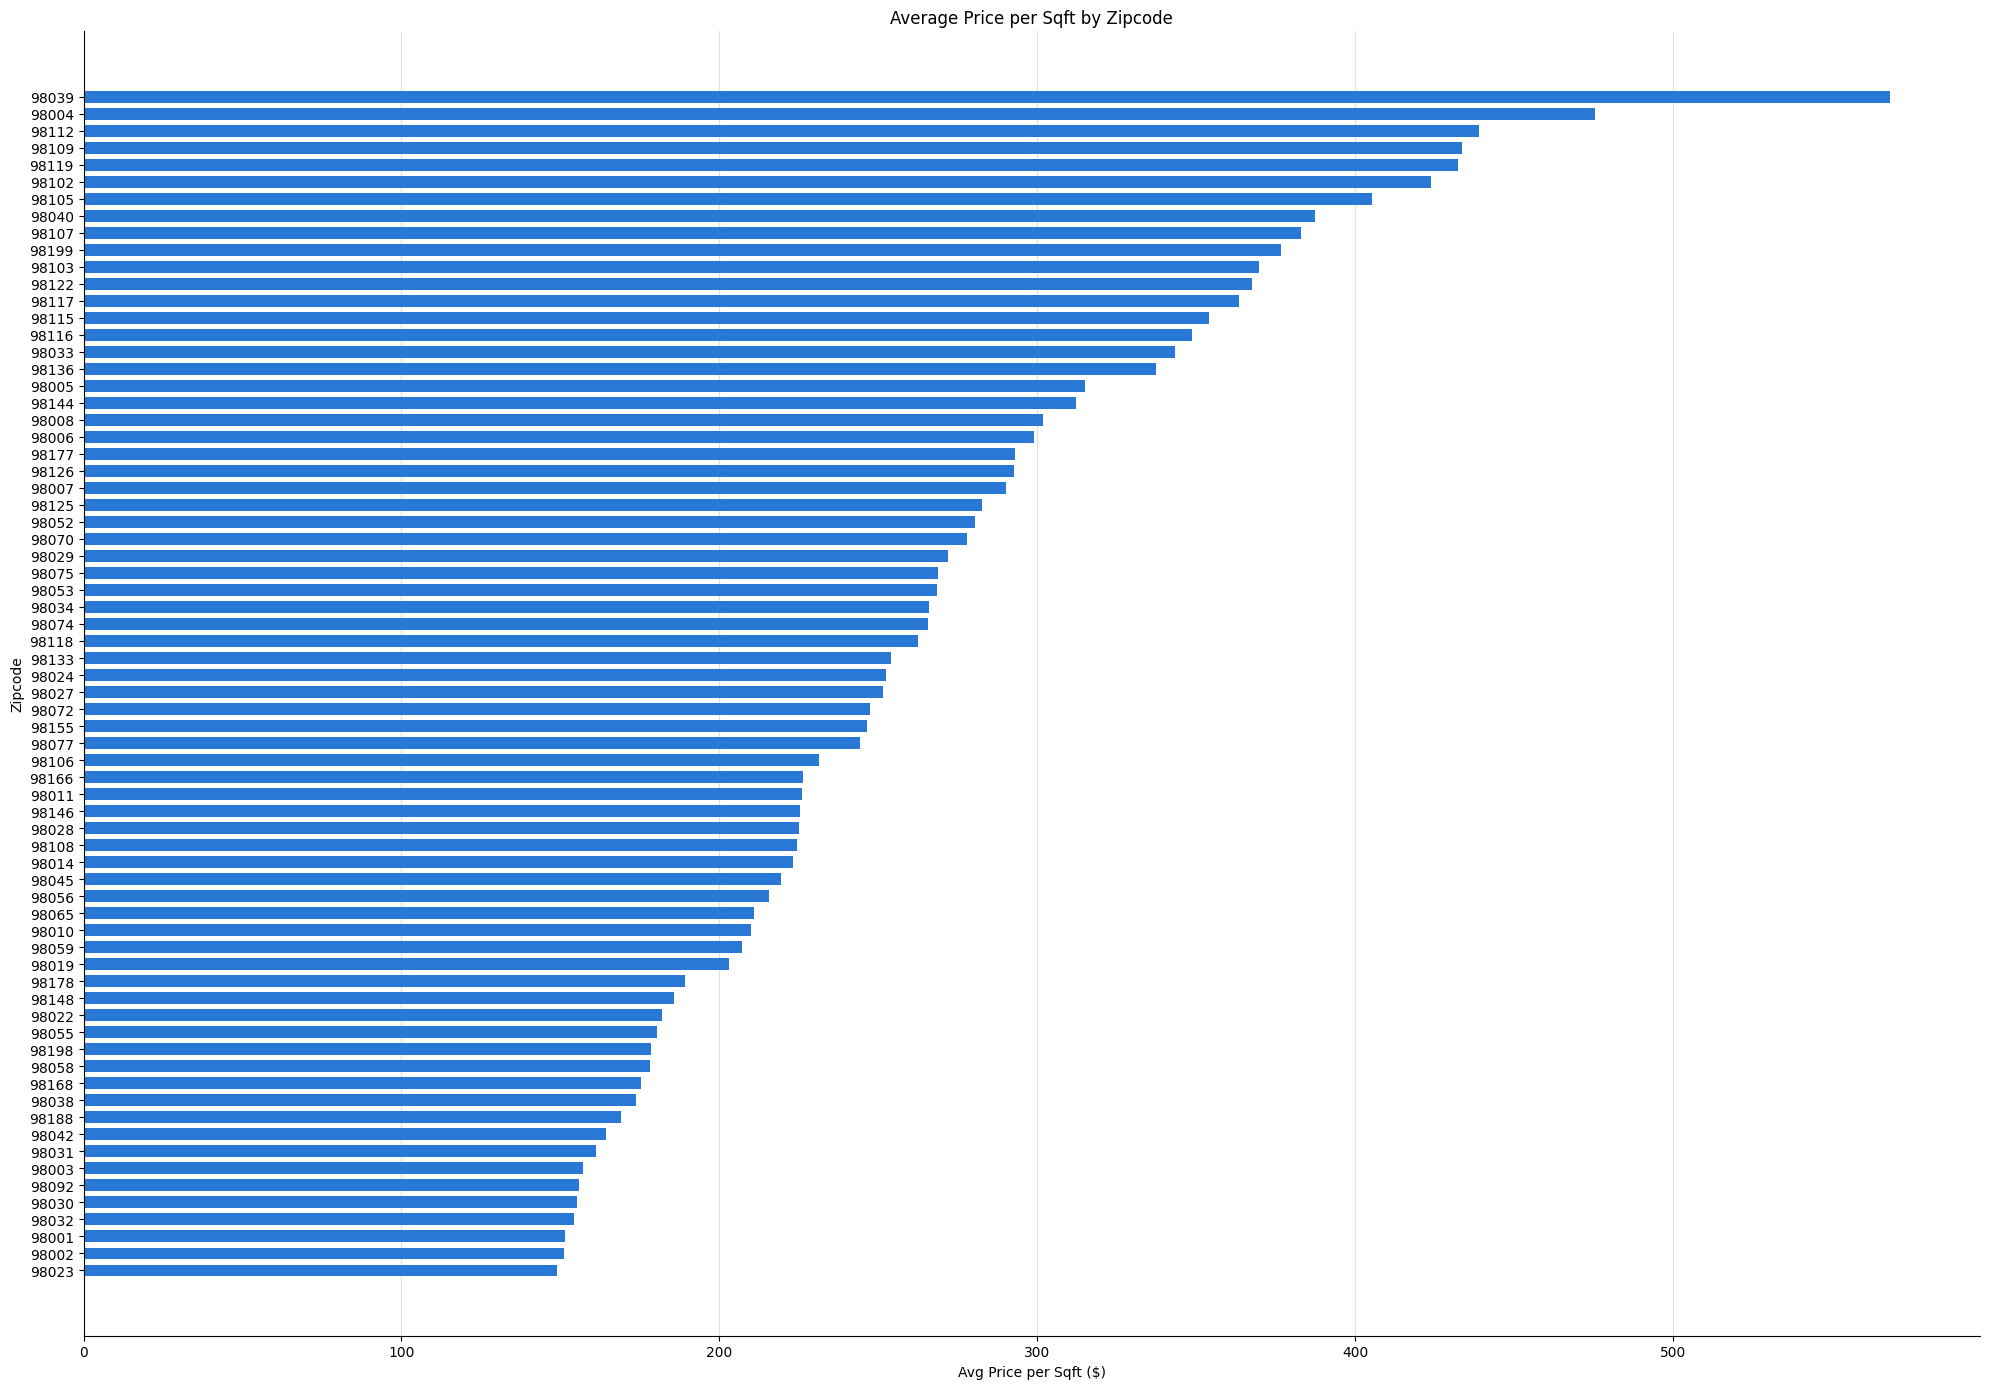

In [62]:
avg_price_per_sqft_sorted = avg_price_per_sqft.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(20, 14))
ax.barh(avg_price_per_sqft_sorted.index.astype(str), avg_price_per_sqft_sorted.values, color='#2a78d6', height=0.7)

ax.set_title('Average Price per Sqft by Zipcode')
ax.set_xlabel('Avg Price per Sqft ($)')
ax.set_ylabel('Zipcode')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## Define "middle-class" zipcodes by price per sqft

Use the 33rd and 67th percentiles of `avg_price_per_sqft` as cutoffs, then keep only the zipcodes whose average price/sqft falls between them (inclusive). This is the tercile method used to define "middle-class" neighborhoods for this analysis — roughly the middle third of zipcodes by price per square foot, not any external income/demographic data. This gives `middle_segment`, the list of middle-class zipcodes.

In [63]:
p33 = avg_price_per_sqft_sorted.quantile(0.33)
p67 = avg_price_per_sqft_sorted.quantile(0.67)

middle_segment = avg_price_per_sqft_sorted[(avg_price_per_sqft_sorted >= p33) & (avg_price_per_sqft_sorted <= p67)]

print(f"33rd percentile: ${p33:.2f}")
print(f"67th percentile: ${p67:.2f}")
print(f"\n{len(middle_segment)} zipcodes fall in this range:\n")
print(middle_segment)


33rd percentile: $218.48
67th percentile: $290.71

24 zipcodes fall in this range:

zipcode
98045    219.356308
98014    223.084512
98108    224.443286
98028    225.145368
98146    225.496990
98011    225.996296
98166    226.220859
98106    231.326952
98077    244.302768
98155    246.525367
98072    247.540842
98027    251.586071
98024    252.327749
98133    253.971453
98118    262.623700
98074    265.686627
98034    265.979212
98053    268.422625
98075    268.685545
98029    272.068868
98070    277.849906
98052    280.390083
98125    282.680191
98007    290.090234
Name: price_per_sqft, dtype: float64


## Tag every house with a price/sqft tier, and compute price per sqft

`tier_from_price_per_sqft` labels a zipcode's average price/sqft as `'bottom'`, `'middle'`, or `'top'` relative to the `p33`/`p67` cutoffs above. Mapping this back onto `df['zipcode']` adds a `zip_tier_pps` column to every house, not just the middle-class subset.

`price_per_sqft` (`price / sqft_living`) normalizes price for house size, so the tiers can be compared without size differences skewing the comparison.

`tier_summary_pps` aggregates by tier to check: is the price/sqft difference between tiers just because houses are bigger in expensive areas, or is location itself commanding a premium?

In [72]:
def tier_from_price_per_sqft(pps):
    if pps < p33:
        return 'bottom'
    elif pps <= p67:
        return 'middle'
    else:
        return 'top'

zip_tier_map_pps = avg_price_per_sqft_sorted.apply(tier_from_price_per_sqft)
df['zip_tier_pps'] = df['zipcode'].map(zip_tier_map_pps)

tier_summary_pps = df.groupby('zip_tier_pps').agg(
    avg_sqft=('sqft_living', 'mean'),
    avg_price_per_sqft=('price_per_sqft', 'mean'),
    n=('price', 'count')
)
print(tier_summary_pps)


                 avg_sqft  avg_price_per_sqft     n
zip_tier_pps                                       
bottom        1994.758391          175.660094  6912
middle        2126.635981          254.801881  7604
top           2114.108318          360.546286  7081


## Compare price across tiers at matched house sizes

A grouped bar chart of average `price` by house-size bucket (`sqft_bucket`, created via `pd.cut` on `sqft_living`), split by `zip_tier_pps`, to check whether the tier price gap holds even among similarly-sized homes (controlling for size directly, rather than relying on the tier average alone).

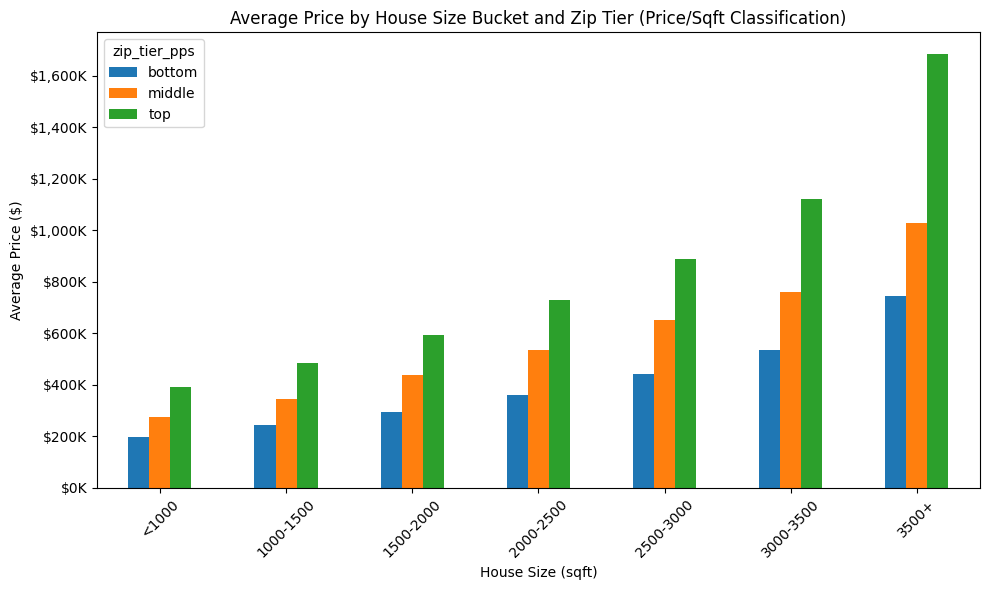

In [65]:
sqft_bins = [0, 1000, 1500, 2000, 2500, 3000, 3500, np.inf]
sqft_labels = ['<1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-3500', '3500+']
df['sqft_bucket'] = pd.cut(df['sqft_living'], bins=sqft_bins, labels=sqft_labels)

bucket_tier_price_pps = df.groupby(['sqft_bucket', 'zip_tier_pps'])['price'].mean().unstack('zip_tier_pps')
bucket_tier_price_pps = bucket_tier_price_pps[['bottom', 'middle', 'top']]

ax = bucket_tier_price_pps.plot(kind='bar', figsize=(10, 6))
ax.set_xlabel('House Size (sqft)')
ax.set_ylabel('Average Price ($)')
ax.set_title('Average Price by House Size Bucket and Zip Tier (Price/Sqft Classification)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Build the final middle-class subset

Filters `df` down to the zipcodes in `middle_segment` (the price/sqft-based "middle-class" definition) to produce `df_middle_class_zip_pps` — the dataset to use for any further "middle-class neighborhood" analysis going forward. `df_middle_class_zip_pps["id"].nunique()` is a quick sanity check on the resulting row/id count.

In [66]:
middle_class_zip_list_pps = middle_segment.index.tolist()
df_middle_class_zip_pps = df[df['zipcode'].isin(middle_class_zip_list_pps)].reset_index(drop=True)
df_middle_class_zip_pps.head()


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,price_per_sqft,zip_tier_pps,sqft_bucket
0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,209.338521,middle,2500-3000
1,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,233.766234,middle,<1000
2,1954400510,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,...,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,303.571429,middle,1500-2000
3,7237550310,4.0,4.50,5420.0,101930.0,1.0,0,0,3,11,...,98053,47.6561,-122.005,4760.0,101930.0,2014-05-12,1230000.0,226.937269,middle,3500+
4,2414600126,3.0,1.00,1780.0,7470.0,1.0,0,0,3,7,...,98146,47.5123,-122.337,1780.0,8113.0,2015-04-15,229500.0,128.932584,middle,1500-2000


In [67]:
df_middle_class_zip_pps["id"].nunique()

7529

In [73]:
df_middle_class_zip_pps.to_pickle("data/middle_class_zip_pps.pkl")

In [75]:
df_middle_class_zip_pps.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,price_per_sqft,zip_tier_pps,sqft_bucket
0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,209.338521,middle,2500-3000
1,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,233.766234,middle,<1000
2,1954400510,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,...,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,303.571429,middle,1500-2000
3,7237550310,4.0,4.50,5420.0,101930.0,1.0,0,0,3,11,...,98053,47.6561,-122.005,4760.0,101930.0,2014-05-12,1230000.0,226.937269,middle,3500+
4,2414600126,3.0,1.00,1780.0,7470.0,1.0,0,0,3,7,...,98146,47.5123,-122.337,1780.0,8113.0,2015-04-15,229500.0,128.932584,middle,1500-2000
